# HyperSense v1.2 — Stage 3: Clinical Enrichment

Stage 3 extends the HyperSense project from the established parsimonious hypertension-risk model to a clinically enriched, Nigeria-specific model using the REMAH cohort.

Stages 1 and 2 evaluated transportability and regional adaptation of the parsimonious six-predictor model. Stage 3 addresses a different question: whether additional clinically relevant anthropometric, behavioural, and laboratory variables improve hypertension risk prediction in the Nigerian population beyond the established model.

This analysis uses the Nigerian REMAH dataset only. Both models are developed and evaluated under the same analytical framework and differ only in their predictor sets:

- **Parsimonious model:** the established HyperSense six-predictor feature set, retrained on REMAH data.
- **Clinically enriched model:** the parsimonious feature set plus additional clinically relevant variables available from the REMAH dataset.

### Outcome

Hypertension is defined according to the published REMAH methodology (Odili et al., 2020) as measured systolic blood pressure ≥140 mmHg and/or diastolic blood pressure ≥90 mmHg and/or current use of antihypertensive medication.

Blood pressure is defined as the average of five consecutive clinic measurements, with all five measurements required. Current antihypertensive treatment is an independent component of the outcome definition; therefore, participants reporting current antihypertensive treatment are classified as hypertensive even when complete blood pressure measurements are unavailable.

`HTN_DR` (`Hypertensive drug therapy`) is used only in outcome construction and is excluded from the predictor sets.

$$
\text{HTN}_{\text{Stage3}} =
\begin{cases}
1, & \text{if complete mean SBP} \geq 140 \text{ or complete mean DBP} \geq 90 \text{ or HTN\_DR}=1 \\
0, & \text{if complete mean SBP}<140 \text{ and complete mean DBP}<90 \text{ and HTN\_DR}\neq1
\end{cases}
$$

### Modelling approach

The primary modelling approach is **XGBoost classification.**

Model development follows the methodological framework established in Stages 1 and 2, including a fixed stratified train/test split, training-only hyperparameter tuning, out-of-fold threshold selection using Youden's index, and evaluation of both discrimination and calibration.

Both models are trained and evaluated on the same analytical cohort and under the same modelling framework, allowing the effect of clinical enrichment to be assessed directly.

### Research question

> Does incorporating additional clinically relevant anthropometric, behavioural, and laboratory variables improve hypertension risk prediction in the Nigerian population beyond the parsimonious HyperSense model?

### Structure

1. Stage 3 Overview
2. Data Loading and Initial Inspection
3. Data Dictionary Mapping and Data Quality Audit
4. Outcome Definition
5. Feature Engineering
6. Missingness and Analytical Cohort
7. Predictor Definition and Leakage Assessment
8. Train/Test Split
9. Parsimonious Model
10. Clinically Enriched Model
11. Hyperparameter Tuning
12. Threshold Selection
13. Final Model Evaluation
14. Parsimonious vs. Enriched Comparison
15. SHAP Explainability
16. Export Results for Reproducibility
17. Stage 3 Conclusion

This structure keeps the major methodological decisions explicit before model development.

In [468]:
# Record package versions for reproducibility

import pandas as pd
import numpy as np
import sklearn
import xgboost

print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost:  {xgboost.__version__}")

pandas:   2.3.3
numpy:    2.4.0
scikit-learn: 1.8.0
xgboost:  3.3.0


In [469]:
# Core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve

from sklearn.base import clone

# Calibration model for estimating calibration intercept and slope
from sklearn.linear_model import LogisticRegression

# XGBoost
from xgboost import XGBClassifier

from pathlib import Path
import json

# Reproducibility
RANDOM_STATE = 99

np.random.seed(RANDOM_STATE)

In [470]:
# Load the REMAH cohort dataset

nigeria = pd.read_excel("../data/REMAH/remah-1.xlsx")

print(f"Nigeria dataset: {len(nigeria):,} rows")

Nigeria dataset: 4,187 rows


In [471]:
# Check all column names
print(nigeria.columns.tolist())

['S_NO', 'PIN', 'SEX', 'EST_AGE', 'DOB', 'AGE', 'SITE', 'EDU_QUA', 'M_STATUS', 'W_STATUS', 'SMK_C', 'SMK_D', 'SMK_D1', 'SMK_D2', 'M_CGRT', 'HR_CGRT', 'PIPE', 'CIGAR', 'SMK_OTHERS', 'SMK_P', 'SMK_P1', 'SMK_P2', 'SMKL', 'SMKL_MO', 'SMKL_NO', 'SMKL_CHEW', 'SMKL_OTHERS', 'SMK_PA_H', 'SMK_PA_WO', 'DRK', 'DRK_12', 'DRK12_FREQ', 'DRK_30', 'WRK_VI', 'WRK_VI_D', 'WRK_VI_T', 'WRK_MI', 'WRK_MI_D', 'WRK_MI_T', 'PA_W', 'PA_W_D', 'PA_W_T', 'SPRT_VI', 'SPRT_VI_D', 'SPRT_VI_T', 'SPRT_MI', 'SPRT_MI_D', 'SPRT_MI_T', 'HTN', 'HTN_DR', 'DM_M', 'DM', 'DM_INS', 'DM_OHA', 'CSBP1', 'CDBP1', 'CSBP2', 'CDBP2', 'CSBP3', 'CDBP3', 'CSBP4', 'CDBP4', 'CSBP5', 'CDBP5', 'PR', 'HT', 'WT', 'WC', 'HC', 'BLD_GLU', 'NA_URINE', 'HDL_CHOL', 'LDL_CHOL', 'TAG', 'TO_CHOL', 'K_URINE']


#### 3. Data Dictionary Mapping and Data Quality Audit

Mapping the pre-specified predictors and outcome variables to the REMAH data dictionary, then assessing coding, missingness, and just basic data quality before feature construction.

In [472]:
# Raw variables required for Stage 3
required_vars = [
    # Outcome
    "HTN",
    "HTN_DR",

    # Blood pressure measurements 
    "CSBP1", "CSBP2", "CSBP3", "CSBP4", "CSBP5",
    "CDBP1", "CDBP2", "CDBP3", "CDBP4", "CDBP5",
    
    # Parsimonious predictors
    "AGE",
    "SEX",
    "EDU_QUA",
    "SITE",
    "SMK_C",
    "SMKL",
    "WT",
    "HT",

    # Enriched predictors
    "PR",
    "M_STATUS",
    "DM",
    "HDL_CHOL",
    "TO_CHOL",
    "LDL_CHOL",
    "SMK_P",
]

# Check which required variables are present
present = [col for col in required_vars if col in nigeria.columns]
missing = [col for col in required_vars if col not in nigeria.columns]

print(f"Present: {len(present)}/{len(required_vars)}")
print(f"Missing: {missing}")

Present: 27/27
Missing: []


In [473]:
# Inspect data types and missingness for Stage 3 variables

audit_vars = required_vars

audit = pd.DataFrame({
    "dtype": nigeria[audit_vars].dtypes.astype(str),
    "missing_n": nigeria[audit_vars].isna().sum(),
    "missing_pct": (nigeria[audit_vars].isna().mean() * 100).round(2),
    "unique_n": nigeria[audit_vars].nunique(dropna=True)
})

audit.sort_values("missing_pct", ascending=False)

,dtype,missing_n,missing_pct,unique_n
HTN_DR,float64,2976,71.08,2
DM,float64,1917,45.78,3
HTN,float64,972,23.21,2
TO_CHOL,float64,785,18.75,573
LDL_CHOL,float64,732,17.48,492
HDL_CHOL,float64,575,13.73,241
SMKL,float64,480,11.46,2
PR,float64,173,4.13,89
SMK_P,float64,135,3.22,2
SMK_C,float64,43,1.03,2


In [474]:
# Inspect categorical variable coding

categorical_vars = [
    "HTN",
    "HTN_DR",
    "SEX",
    "EDU_QUA",
    "SITE",
    "M_STATUS",
    "SMK_C",
    "SMKL",
    "SMK_P",
    "DM"
]

for col in categorical_vars:
    print(f"\n--- {col} ---")
    print(nigeria[col].value_counts(dropna=False).sort_index())


--- HTN ---
HTN
1.0    1030
2.0    2185
NaN     972
Name: count, dtype: int64

--- HTN_DR ---
HTN_DR
1.0     495
2.0     716
NaN    2976
Name: count, dtype: int64

--- SEX ---
SEX
1    1814
2    2373
Name: count, dtype: int64

--- EDU_QUA ---
EDU_QUA
1.0      658
2.0      193
3.0      707
4.0     1158
5.0     1131
7.0      299
55.0       1
88.0       1
NaN       39
Name: count, dtype: int64

--- SITE ---
SITE
1    2171
2    2016
Name: count, dtype: int64

--- M_STATUS ---
M_STATUS
1.0      922
2.0     2758
3.0       29
4.0       27
5.0      427
6.0        9
88.0       2
NaN       13
Name: count, dtype: int64

--- SMK_C ---
SMK_C
1.0     166
2.0    3978
NaN      43
Name: count, dtype: int64

--- SMKL ---
SMKL
1.0      98
2.0    3609
NaN     480
Name: count, dtype: int64

--- SMK_P ---
SMK_P
1.0     311
2.0    3741
NaN     135
Name: count, dtype: int64

--- DM ---
DM
1.0     208
2.0    2061
5.0       1
NaN    1917
Name: count, dtype: int64


In [475]:
# Blood pressure measurement completeness

bp_vars = [
    "CSBP1", "CSBP2", "CSBP3", "CSBP4", "CSBP5",
    "CDBP1", "CDBP2", "CDBP3", "CDBP4", "CDBP5"
]

bp_audit = pd.DataFrame({
    "missing_n": nigeria[bp_vars].isna().sum(),
    "missing_pct": (nigeria[bp_vars].isna().mean() * 100).round(2)
})

bp_audit

,missing_n,missing_pct
CSBP1,4,0.10
CSBP2,4,0.10
CSBP3,3,0.07
CSBP4,4,0.10
CSBP5,16,0.38
CDBP1,5,0.12
CDBP2,4,0.10
CDBP3,3,0.07
CDBP4,4,0.10
CDBP5,18,0.43


In [476]:
# Categorical codes according to the data dictionary

expected_codes = {
    "HTN": {1, 2},
    "HTN_DR": {1, 2},
    "SEX": {1, 2},
    "EDU_QUA": {1, 2, 3, 4, 5, 7, 88},
    "SITE": {1, 2},
    "M_STATUS": {1, 2, 3, 4, 5, 6, 88},
    "SMK_C": {1, 2},
    "SMKL": {1, 2},
    "SMK_P": {1, 2},
    "DM": {1, 2},
}

for col, valid_codes in expected_codes.items():
    observed = set(nigeria[col].dropna().unique())
    unexpected = sorted(observed - valid_codes)

    print(f"{col}:")
    print(f"  Observed: {sorted(observed)}")
    print(f"  Unexpected: {unexpected if unexpected else 'None'}")
    print()

HTN:
  Observed: [np.float64(1.0), np.float64(2.0)]
  Unexpected: None

HTN_DR:
  Observed: [np.float64(1.0), np.float64(2.0)]
  Unexpected: None

SEX:
  Observed: [np.int64(1), np.int64(2)]
  Unexpected: None

EDU_QUA:
  Observed: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(55.0), np.float64(88.0)]
  Unexpected: [np.float64(55.0)]

SITE:
  Observed: [np.int64(1), np.int64(2)]
  Unexpected: None

M_STATUS:
  Observed: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(88.0)]
  Unexpected: None

SMK_C:
  Observed: [np.float64(1.0), np.float64(2.0)]
  Unexpected: None

SMKL:
  Observed: [np.float64(1.0), np.float64(2.0)]
  Unexpected: None

SMK_P:
  Observed: [np.float64(1.0), np.float64(2.0)]
  Unexpected: None

DM:
  Observed: [np.float64(1.0), np.float64(2.0), np.float64(5.0)]
  Unexpected: [np.float64(5.0)]



In [477]:
# Range and plausibility checks for continuous variables

continuous_vars = [
    "AGE",
    "HT",
    "WT",
    "PR",
    "HDL_CHOL",
    "TO_CHOL",
    "LDL_CHOL",
]

continuous_audit = nigeria[continuous_vars].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

continuous_audit["missing_n"] = nigeria[continuous_vars].isna().sum()
continuous_audit["missing_pct"] = (
    nigeria[continuous_vars].isna().mean() * 100
).round(2)

continuous_audit

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_n,missing_pct
AGE,4183.0,43.835090,16.297721,14.509589,18.321315,20.484932,30.660274,41.958904,55.142466,72.950137,83.263726,98.791781,4,0.10
HT,4164.0,163.419476,8.792892,131.000000,145.000000,150.000000,157.000000,163.000000,169.125000,179.000000,185.000000,195.000000,23,0.55
WT,4163.0,65.348475,14.779346,30.000000,40.000000,45.000000,55.000000,63.000000,74.000000,93.000000,109.000000,136.000000,24,0.57
PR,4014.0,73.609367,12.657101,7.000000,50.000000,56.000000,65.000000,72.000000,81.000000,96.000000,110.870000,138.000000,173,4.13
HDL_CHOL,3612.0,0.812947,0.562132,0.000000,0.010000,0.160000,0.430000,0.750000,1.050000,1.894500,2.595600,10.100000,575,13.73
TO_CHOL,3402.0,3.205344,1.328088,0.010000,0.830000,1.170000,2.170000,3.190000,4.170000,5.379500,6.300000,9.000000,785,18.75
LDL_CHOL,3455.0,1.995386,1.154278,0.000000,0.090000,0.320000,1.040000,1.960000,2.810000,3.930000,4.799200,8.800000,732,17.48


In [478]:
# Inspect the observed ranges of the five clinic BP readings

bp_summary = nigeria[bp_vars].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T

bp_summary["missing_n"] = nigeria[bp_vars].isna().sum()
bp_summary["missing_pct"] = (
    nigeria[bp_vars].isna().mean() * 100
).round(2)

bp_summary

,count,mean,std,min,1%,5%,50%,95%,99%,max,missing_n,missing_pct
CSBP1,4183.0,127.035381,24.217771,60.0,90.0,96.0,122.0,172.0,200.0,250.0,4,0.10
CSBP2,4183.0,126.546498,23.868516,64.0,88.0,96.0,122.0,172.0,198.0,252.0,4,0.10
CSBP3,4184.0,126.137906,23.618215,64.0,88.0,96.0,122.0,170.0,198.0,254.0,3,0.07
CSBP4,4183.0,125.718623,23.366181,66.0,88.0,96.0,122.0,170.0,198.0,256.0,4,0.10
CSBP5,4171.0,125.562455,23.336731,64.0,88.0,96.0,122.0,170.0,198.0,254.0,16,0.38
CDBP1,4182.0,78.027021,13.606349,40.0,52.0,60.0,78.0,102.0,116.0,162.0,5,0.12
CDBP2,4183.0,78.266316,13.482345,40.0,52.0,60.0,78.0,102.0,114.0,160.0,4,0.10
CDBP3,4184.0,78.299474,13.525423,40.0,52.0,60.0,78.0,102.0,116.0,168.0,3,0.07
CDBP4,4183.0,78.237628,13.560585,40.0,52.0,58.0,76.0,102.0,116.0,168.0,4,0.10
CDBP5,4169.0,78.253778,13.591055,22.0,52.0,60.0,78.0,102.0,114.0,168.0,18,0.43


#### 4. Outcome Definition

Construct the Stage 3 hypertension outcome from the five clinic BP measurements and current antihypertensive drug therapy (`HTN_DR`).

In [479]:
# Calculate mean clinic SBP and DBP only when all five readings are available

bp_complete = nigeria[bp_vars].notna().all(axis=1)

nigeria["MEAN_SBP"] = nigeria[
    ["CSBP1", "CSBP2", "CSBP3", "CSBP4", "CSBP5"]
].mean(axis=1, skipna=False)

nigeria["MEAN_DBP"] = nigeria[
    ["CDBP1", "CDBP2", "CDBP3", "CDBP4", "CDBP5"]
].mean(axis=1, skipna=False)

print(f"Complete 5-reading BP: {bp_complete.sum():,}")
print(f"Incomplete 5-reading BP: {(~bp_complete).sum():,}")

Complete 5-reading BP: 4,167
Incomplete 5-reading BP: 20


In [480]:
# Stage 3 hypertension outcome:
# measured hypertension OR current antihypertensive treatment.

measured_htn = (
    bp_complete
    & (
        (nigeria["MEAN_SBP"] >= 140)
        | (nigeria["MEAN_DBP"] >= 90)
    )
)

treated_htn = nigeria["HTN_DR"].eq(1)

nigeria["HTN_STAGE3"] = (
    measured_htn | treated_htn
).astype(int)

In [481]:
# Outcome summary
outcome_summary = nigeria["HTN_STAGE3"].value_counts().sort_index()

print(outcome_summary)
print(f"\nHypertension prevalence: {nigeria['HTN_STAGE3'].mean():.4f}")

HTN_STAGE3
0    2831
1    1356
Name: count, dtype: int64

Hypertension prevalence: 0.3239


In [482]:
print("Measured hypertension:", measured_htn.sum())
print("Treatment-positive:", treated_htn.sum())
print("Both:", (measured_htn & treated_htn).sum())
print("Total hypertension:", nigeria["HTN_STAGE3"].sum())

Measured hypertension: 1180
Treatment-positive: 495
Both: 319
Total hypertension: 1356


#### 5. Feature Engineering

Create the pre-specified predictor variables from the REMAH measurements and questionnaire responses.

In [483]:
# Reload the raw REMAH dataset to keep the source data untouched.
nigeria_raw = pd.read_excel("../data/REMAH/remah-1.xlsx")

# All derived variables for Stage 3 will be created here:
analysis = nigeria_raw.copy()

print(f"Raw dataset: {nigeria_raw.shape}")
print(f"Analytical dataframe: {analysis.shape}")

Raw dataset: (4187, 76)
Analytical dataframe: (4187, 76)


In [484]:
# Reconstructing the outcome variable

# Five-reading clinic BP means
bp_complete = analysis[bp_vars].notna().all(axis=1)

analysis["MEAN_SBP"] = analysis[
    ["CSBP1", "CSBP2", "CSBP3", "CSBP4", "CSBP5"]
].mean(axis=1, skipna=False)

analysis["MEAN_DBP"] = analysis[
    ["CDBP1", "CDBP2", "CDBP3", "CDBP4", "CDBP5"]
].mean(axis=1, skipna=False)

# Stage 3 hypertension outcome
measured_htn = (
    bp_complete
    & (
        (analysis["MEAN_SBP"] >= 140)
        | (analysis["MEAN_DBP"] >= 90)
    )
)

treated_htn = analysis["HTN_DR"].eq(1)

analysis["HTN_STAGE3"] = (
    measured_htn | treated_htn
).astype(int)

print(analysis["HTN_STAGE3"].value_counts().sort_index())

HTN_STAGE3
0    2831
1    1356
Name: count, dtype: int64


In [485]:
# Core continuous and anthropometric predictors

analysis["AGE_YEARS"] = analysis["AGE"].round().astype("Int64")

analysis["BMI"] = (
    analysis["WT"] / (analysis["HT"] / 100) ** 2
)

In [486]:
# Binary predictor representations

analysis["SEX_BIN"] = analysis["SEX"].map({
    1: 0,  # Male
    2: 1   # Female
})

analysis["RESIDENCE_BIN"] = analysis["SITE"].map({
    1: 0,  # Rural
    2: 1   # Urban
})

analysis["DIABETES"] = analysis["DM"].where(
    analysis["DM"].isin([1, 2])
).map({
    1: 1,
    2: 0
})

In [487]:
# Identify observations with implausible age for the REMAH adult cohort
# based on the descriptive characteristics explored earleir

analysis.loc[
    analysis["AGE"] < 18,
    ["S_NO", "PIN", "AGE", "DOB", "SEX", "HT", "WT"]
].sort_values("AGE")

,S_NO,PIN,AGE,DOB,SEX,HT,WT
2151,2156,41030002,14.509589,2003-02-02,2,160.3,69.0
1347,1349,31032002,17.553425,1999-10-31,2,167.0,53.0
1967,1971,41145003,17.621918,2000-01-08,1,168.5,66.0
440,442,11024005,17.687671,1999-08-08,2,163.0,60.0
2139,2144,41003001,17.712329,1999-11-18,1,185.5,76.0
3614,3622,60114004,17.726027,2000-07-01,1,161.0,64.0
1230,1232,31010004,17.780822,1999-08-19,2,160.0,55.0
648,650,21076003,17.857534,1999-06-20,2,161.0,52.0
1720,1723,33034004,17.920548,1999-07-16,2,160.0,50.0
2119,2123,41060004,17.923288,1999-09-09,2,150.0,57.0


In [488]:
print("Participants with AGE < 18:", (analysis["AGE"] < 18).sum())
# I expect the output of <18 to be 10 according to the table above

print("Participants with AGE >= 100:", (analysis["AGE"] >= 100).sum())

Participants with AGE < 18: 11
Participants with AGE >= 100: 0


In [489]:
# Apply the adult eligibility criterion after rounding age to whole years.
analysis["AGE_YEARS"] = analysis["AGE"].round()

analysis = analysis.loc[
    analysis["AGE_YEARS"] >= 18
].copy()

print(f"Analytical cohort: {len(analysis):,} participants")

Analytical cohort: 4,182 participants


In [490]:
# Categorical feature engineering..

# Education: retain the established four-level HyperSense representation.
education_map = {
    1: 0,  # No formal schooling
    2: 1,  # < Primary
    3: 1,  # Primary completed
    4: 2,  # Secondary completed
    5: 3,  # COE/Poly/Uni completed
    7: 3,  # Postgraduate degree
    55: np.nan, # earlier diagnostics showed an inconsistent value of 55 not supported by the data dictionary
    88: np.nan,
}

analysis["EDUCATION_LEVEL"] = analysis["EDU_QUA"].map(education_map)

In [491]:
# Tobacco use: current smoking OR current smokeless tobacco use.
smoking = analysis["SMK_C"]
smokeless = analysis["SMKL"]

analysis["TOBACCO_USE"] = np.where(
    smoking.isna() & smokeless.isna(),
    np.nan,
    ((smoking == 1) | (smokeless == 1)).astype(int)
)

In [492]:
# Enriched tobacco status:
# Current = current smoking or current smokeless tobacco use
# Past    = past tobacco use without current use
# None    = no current or past tobacco use

analysis["TOBACCO_STATUS"] = pd.Series(
    pd.NA,
    index=analysis.index,
    dtype="object"
)

current_tobacco = (
    (analysis["SMK_C"] == 1) |
    (analysis["SMKL"] == 1)
)

past_tobacco = analysis["SMK_P"] == 1

smoking_complete = analysis[
    ["SMK_C", "SMKL", "SMK_P"]
].notna().all(axis=1)

analysis.loc[current_tobacco, "TOBACCO_STATUS"] = "Current"

analysis.loc[
    ~current_tobacco & past_tobacco,
    "TOBACCO_STATUS"
] = "Past"

analysis.loc[
    ~current_tobacco & ~past_tobacco & smoking_complete,
    "TOBACCO_STATUS"
] = "None"

In [493]:
analysis["TOBACCO_STATUS"].value_counts(dropna=False)

TOBACCO_STATUS
None       3225
<NA>        483
Current     248
Past        226
Name: count, dtype: int64

In [494]:
# Collapse marital status into three categories.

marital_map = {
    1: "Never married",
    2: "Married/Cohabiting",
    3: "Previously married",
    4: "Previously married",
    5: "Previously married",
    6: "Married/Cohabiting",
}

analysis["MARITAL_STATUS"] = analysis["M_STATUS"].map(marital_map)

analysis["MARITAL_STATUS"].value_counts(dropna=False)

MARITAL_STATUS
Married/Cohabiting    2765
Never married          921
Previously married     482
NaN                     14
Name: count, dtype: int64

In [495]:
# Diagnosed diabetes: 1 = Yes, 0 = No; invalid/refused values remain missing.

analysis["DIABETES"] = analysis["DM"].where(
    analysis["DM"].isin([1, 2])
).map({
    1: 1,
    2: 0
})

In [496]:
categorical_features = [
    "EDUCATION_LEVEL",
    "TOBACCO_USE",
    "TOBACCO_STATUS",
    "MARITAL_STATUS",
    "DIABETES",
]

for col in categorical_features:
    print(f"\n--- {col} ---")
    print(analysis[col].value_counts(dropna=False))


--- EDUCATION_LEVEL ---
EDUCATION_LEVEL
3.0    1430
2.0    1157
1.0     898
0.0     657
NaN      40
Name: count, dtype: int64

--- TOBACCO_USE ---
TOBACCO_USE
0.0    3913
1.0     248
NaN      21
Name: count, dtype: int64

--- TOBACCO_STATUS ---
TOBACCO_STATUS
None       3225
<NA>        483
Current     248
Past        226
Name: count, dtype: int64

--- MARITAL_STATUS ---
MARITAL_STATUS
Married/Cohabiting    2765
Never married          921
Previously married     482
NaN                     14
Name: count, dtype: int64

--- DIABETES ---
DIABETES
0.0    2060
NaN    1914
1.0     208
Name: count, dtype: int64


In [497]:
# Continuous enriched predictors

analysis["PULSE_RATE"] = analysis["PR"]

analysis["HDL"] = analysis["HDL_CHOL"]
analysis["TOTAL_CHOL"] = analysis["TO_CHOL"]
analysis["LDL"] = analysis["LDL_CHOL"]

In [498]:
continuous_features = [
    "AGE_YEARS",
    "BMI",
    "PR",
    "HDL",
    "TOTAL_CHOL",
    "LDL",
]

feature_audit = analysis[continuous_features].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T

feature_audit["missing_n"] = analysis[continuous_features].isna().sum()
feature_audit["missing_pct"] = (
    analysis[continuous_features].isna().mean() * 100
).round(2)

feature_audit

,count,mean,std,min,1%,5%,50%,95%,99%,max,missing_n,missing_pct
AGE_YEARS,4182.0,43.814682,16.286051,18.000000,18.000000,21.000000,42.000000,73.00000,83.000000,99.00000,0,0.00
BMI,4159.0,24.434548,5.106212,11.667733,16.262976,17.895702,23.422091,34.17489,39.858646,56.29574,23,0.55
PR,4011.0,73.607330,12.660112,7.000000,50.000000,56.000000,72.000000,96.00000,110.900000,138.00000,171,4.09
HDL,3609.0,0.813301,0.562162,0.000000,0.010000,0.160000,0.750000,1.89600,2.596800,10.10000,573,13.70
TOTAL_CHOL,3399.0,3.203939,1.327196,0.010000,0.829800,1.170000,3.190000,5.37100,6.300000,9.00000,783,18.72
LDL,3452.0,1.994050,1.153319,0.000000,0.090000,0.320000,1.960000,3.93000,4.784900,8.80000,730,17.46


In [499]:
# Audit derived BMI and waist-to-hip ratio

analysis[["HT", "WT", "WC", "HC", "BMI"]].describe().T

,count,mean,std,min,25%,50%,75%,max
HT,4160.0,163.431346,8.786869,131.000000,157.000000,163.000000,169.625000,195.00000
WT,4159.0,65.356023,14.776726,30.000000,55.000000,63.000000,74.000000,136.00000
WC,4137.0,85.628475,12.087727,29.000000,77.000000,84.000000,93.000000,139.00000
HC,4135.0,95.811366,11.078107,25.000000,88.000000,95.000000,102.000000,154.00000
BMI,4159.0,24.434548,5.106212,11.667733,20.811655,23.422091,27.141582,56.29574


In [500]:
# Inspect extreme derived-feature observations
print("Lowest pulse rates:")
display(
    analysis.loc[analysis["PR"].nsmallest(10).index,
                 ["S_NO", "PIN", "AGE_YEARS", "PR"]]
)

print("\nLowest BMI values:")
display(
    analysis.loc[analysis["BMI"].nsmallest(10).index,
                 ["S_NO", "PIN", "AGE_YEARS", "HT", "WT", "BMI"]]
)

Lowest pulse rates:


,S_NO,PIN,AGE_YEARS,PR
3974,3983,61001027,58.0,7.0
799,801,20009003,47.0,23.0
614,616,21003021,40.0,39.0
1969,1973,41136003,35.0,40.0
447,449,11010024,76.0,42.0
1205,1207,32060001,67.0,42.0
1802,1806,41186004,35.0,42.0
76,77,11008002,55.0,43.0
940,942,20132001,67.0,43.0
3638,3646,60126003,22.0,43.0



Lowest BMI values:


,S_NO,PIN,AGE_YEARS,HT,WT,BMI
1148,1150,32045003,65.0,163.0,31.0,11.667733
754,756,20038001,75.0,148.0,30.0,13.696129
1145,1147,32030002,57.0,160.0,37.0,14.453125
599,601,21036007,45.0,150.0,33.0,14.666667
1294,1296,33040004,78.0,150.0,33.0,14.666667
1638,1641,33013002,65.0,150.0,33.0,14.666667
1060,1062,32005002,25.0,167.0,41.0,14.701137
1144,1146,32035003,75.0,154.0,35.0,14.757969
2118,2122,41060002,21.0,170.2,43.0,14.843945
642,644,21074004,26.0,168.0,42.0,14.880952


In [501]:
# Inspect the lowest pulse-rate observations in the raw clinical context

analysis.loc[
    analysis["PR"].nsmallest(5).index,
    ["S_NO", "PIN", "AGE_YEARS", "SEX", "PR", "CSBP1", "CDBP1",
     "CSBP2", "CDBP2", "CSBP3", "CDBP3", "CSBP4", "CDBP4",
     "CSBP5", "CDBP5"]
]

,S_NO,PIN,AGE_YEARS,SEX,PR,CSBP1,CDBP1,CSBP2,CDBP2,CSBP3,CDBP3,CSBP4,CDBP4,CSBP5,CDBP5
3974,3983,61001027,58.0,1,7.0,148.0,84.0,150.0,84.0,144.0,82.0,146.0,84.0,140.0,80.0
799,801,20009003,47.0,1,23.0,180.0,74.0,178.0,76.0,176.0,80.0,178.0,74.0,182.0,76.0
614,616,21003021,40.0,1,39.0,142.0,62.0,144.0,64.0,148.0,68.0,148.0,60.0,150.0,60.0
1969,1973,41136003,35.0,1,40.0,100.0,72.0,100.0,70.0,104.0,72.0,100.0,72.0,100.0,72.0
447,449,11010024,76.0,1,42.0,164.0,80.0,160.0,84.0,154.0,80.0,154.0,78.0,154.0,82.0


In [502]:
# Treat the implausible PR=7 observation as missing.
analysis.loc[analysis["PR"] == 7, "PR"] = np.nan

# Enriched continuous predictor
analysis["PULSE_RATE"] = analysis["PR"]

In [503]:
# Check if fix worked:

print("PR = 7 remaining:", (analysis["PR"] == 7).sum())
print("Missing pulse rate:", analysis["PULSE_RATE"].isna().sum())

PR = 7 remaining: 0
Missing pulse rate: 172


One pulse-rate value (7 bpm) was identified as implausible and inconsistent with the participant's clinical measurements. The value was treated as missing rather than replaced with an inferred value.

In [504]:
# Section 5 checkpoint: final engineered predictor sets

parsimonious_features = [
    "AGE_YEARS",
    "SEX_BIN",
    "EDUCATION_LEVEL",
    "RESIDENCE_BIN",
    "TOBACCO_USE",
    "BMI",
]

enriched_features = [
    "AGE_YEARS",
    "SEX_BIN",
    "EDUCATION_LEVEL",
    "RESIDENCE_BIN",
    "BMI",
    "PULSE_RATE",
    "MARITAL_STATUS",
    "DIABETES",
    "HDL",
    "TOTAL_CHOL",
    "LDL",
    "TOBACCO_STATUS",
]

print("=" * 60)
print("STAGE 3 — SECTION 5: FEATURE ENGINEERING CHECKPOINT")
print("=" * 60)

print(f"\nAnalytical cohort: {len(analysis):,} participants")

print(f"\nParsimonious model ({len(parsimonious_features)} predictors):")
print(parsimonious_features)

print(f"\nClinically enriched model ({len(enriched_features)} predictors):")
print(enriched_features)

print("\nOutcome distribution:")
print(
    analysis["HTN_STAGE3"]
    .value_counts()
    .sort_index()
    .rename({
        0: "Non-hypertensive",
        1: "Hypertensive"
    })
)

STAGE 3 — SECTION 5: FEATURE ENGINEERING CHECKPOINT

Analytical cohort: 4,182 participants

Parsimonious model (6 predictors):
['AGE_YEARS', 'SEX_BIN', 'EDUCATION_LEVEL', 'RESIDENCE_BIN', 'TOBACCO_USE', 'BMI']

Clinically enriched model (12 predictors):
['AGE_YEARS', 'SEX_BIN', 'EDUCATION_LEVEL', 'RESIDENCE_BIN', 'BMI', 'PULSE_RATE', 'MARITAL_STATUS', 'DIABETES', 'HDL', 'TOTAL_CHOL', 'LDL', 'TOBACCO_STATUS']

Outcome distribution:
HTN_STAGE3
Non-hypertensive    2829
Hypertensive        1353
Name: count, dtype: int64


#### 6. Missingness and Analytical Cohort

Assess missingness in the final predictor sets and define the common analytical cohort used for both models.

In [505]:
# Missingness in the final predictor sets

all_features = list(dict.fromkeys(
    parsimonious_features + enriched_features
))

missingness = pd.DataFrame({
    "missing_n": analysis[all_features].isna().sum(),
    "missing_pct": (
        analysis[all_features].isna().mean() * 100
    ).round(2)
})

missingness.sort_values("missing_pct", ascending=False)

,missing_n,missing_pct
DIABETES,1914,45.77
TOTAL_CHOL,783,18.72
LDL,730,17.46
HDL,573,13.70
TOBACCO_STATUS,483,11.55
PULSE_RATE,172,4.11
EDUCATION_LEVEL,40,0.96
BMI,23,0.55
TOBACCO_USE,21,0.50
MARITAL_STATUS,14,0.33


In [506]:
# Common analytical cohort:
# complete outcome + complete parsimonious predictors

parsimonious_complete = analysis[parsimonious_features].notna().all(axis=1)

analysis_cohort = analysis.loc[
    parsimonious_complete
].copy()

print(f"Eligible participants: {len(analysis):,}")
print(f"Analytical cohort:     {len(analysis_cohort):,}")
print(f"Excluded:              {len(analysis) - len(analysis_cohort):,}")

Eligible participants: 4,182
Analytical cohort:     4,105
Excluded:              77


In [507]:
# Outcome distribution in the analytical cohort

print(
    analysis_cohort["HTN_STAGE3"]
    .value_counts()
    .sort_index()
    .rename({
        0: "Non-hypertensive",
        1: "Hypertensive"
    })
)

print(
    f"\nHypertension prevalence: "
    f"{analysis_cohort['HTN_STAGE3'].mean():.4f}"
)

HTN_STAGE3
Non-hypertensive    2781
Hypertensive        1324
Name: count, dtype: int64

Hypertension prevalence: 0.3225


#### 7. Predictor Definition and Leakage Assessment

Freeze the final predictor sets and verify that variables representing the outcome or its management are excluded.

In [508]:
# Final pre-specified predictor sets

parsimonious_features = [
    "AGE_YEARS",
    "SEX_BIN",
    "EDUCATION_LEVEL",
    "RESIDENCE_BIN",
    "TOBACCO_USE",
    "BMI",
]

enriched_features = [
    "AGE_YEARS",
    "SEX_BIN",
    "EDUCATION_LEVEL",
    "RESIDENCE_BIN",
    "BMI",
    "PULSE_RATE",
    "MARITAL_STATUS",
    "DIABETES",
    "HDL",
    "TOTAL_CHOL",
    "LDL",
    "TOBACCO_STATUS",
]

In [509]:
# Variables excluded because they directly define or reflect
# hypertension diagnosis, treatment, or management.

leakage_excluded = [
    "HTN",
    "HTN_DR",
    "HTN_HERBS",
    "HTN_SALT",
    "HTN_WT",
    "HTN_SMK",
    "HTN_EX",
    "HTN_TRADO",
    "DM_OHA",
    "DM_INS",
]

all_predictors = parsimonious_features + enriched_features

leakage_present = [
    var for var in leakage_excluded
    if var in all_predictors
]

print("Leakage variables present in predictor sets:", leakage_present)

Leakage variables present in predictor sets: []


In [510]:
# Confirm that the two models use the intended predictor architecture.

print(f"Parsimonious predictors: {len(parsimonious_features)}")
print(f"Enriched predictors:     {len(enriched_features)}")

print("\nParsimonious:")
print(parsimonious_features)

print("\nEnriched:")
print(enriched_features)

Parsimonious predictors: 6
Enriched predictors:     12

Parsimonious:
['AGE_YEARS', 'SEX_BIN', 'EDUCATION_LEVEL', 'RESIDENCE_BIN', 'TOBACCO_USE', 'BMI']

Enriched:
['AGE_YEARS', 'SEX_BIN', 'EDUCATION_LEVEL', 'RESIDENCE_BIN', 'BMI', 'PULSE_RATE', 'MARITAL_STATUS', 'DIABETES', 'HDL', 'TOTAL_CHOL', 'LDL', 'TOBACCO_STATUS']


#### 8. Train/Test Split

Create a single stratified train/test split shared by both models.

In [511]:
# Shared stratified train/test split for both models

train_idx, test_idx = train_test_split(
    analysis_cohort.index,
    test_size=0.20,
    stratify=analysis_cohort["HTN_STAGE3"],
    random_state=RANDOM_STATE
)

train = analysis_cohort.loc[train_idx].copy()
test = analysis_cohort.loc[test_idx].copy()

print(f"Training set: {len(train):,} participants")
print(f"Test set:     {len(test):,} participants")

Training set: 3,284 participants
Test set:     821 participants


In [512]:
# Verify outcome distribution across the split

split_summary = pd.DataFrame({
    "Training": train["HTN_STAGE3"].value_counts(normalize=True),
    "Test": test["HTN_STAGE3"].value_counts(normalize=True),
}).sort_index()

split_summary.index = ["Non-hypertensive", "Hypertensive"]

split_summary

,Training,Test
Non-hypertensive,0.677527,0.677223
Hypertensive,0.322473,0.322777


In [513]:
# Confirm that the train and test sets are disjoint and exhaustive

print("Overlap:", len(set(train.index) & set(test.index)))
print("Combined:", len(train) + len(test))
print("Analytical cohort:", len(analysis_cohort))

Overlap: 0
Combined: 4105
Analytical cohort: 4105


#### 9. Parsimonious Model

Train the established six-predictor HyperSense model on the training set.

In [514]:
# Parsimonious model inputs

X_train_parsimonious = train[parsimonious_features].copy()
X_test_parsimonious = test[parsimonious_features].copy()

y_train = train["HTN_STAGE3"]
y_test = test["HTN_STAGE3"]

print(f"Training features: {X_train_parsimonious.shape}")
print(f"Test features:     {X_test_parsimonious.shape}")

Training features: (3284, 6)
Test features:     (821, 6)


In [515]:
# Initial parsimonious XGBoost model
parsimonious_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)

parsimonious_model.fit(
    X_train_parsimonious,
    y_train
)

print("Parsimonious XGBoost model fitted.")

Parsimonious XGBoost model fitted.


In [516]:
# Test-set predicted probabilities
parsimonious_test_proba = parsimonious_model.predict_proba(
    X_test_parsimonious
)[:, 1]

parsimonious_test_proba[:5]

array([0.46271825, 0.0442074 , 0.12649007, 0.3584477 , 0.07342509],
      dtype=float32)

#### 10. Clinically Enriched Model

Train the pre-specified clinically enriched XGBoost model on the same training and test split.

In [517]:
# Enriched model inputs
X_train_enriched = train[enriched_features].copy()
X_test_enriched = test[enriched_features].copy()

# Explicit categorical levels for nominal predictors
categorical_levels = {
    "MARITAL_STATUS": [
        "Never married",
        "Married/Cohabiting",
        "Previously married",
    ],
    "TOBACCO_STATUS": [
        "None",
        "Current",
        "Past",
    ],
}

for col, levels in categorical_levels.items():
    dtype = pd.CategoricalDtype(categories=levels)
    X_train_enriched[col] = X_train_enriched[col].astype(dtype)
    X_test_enriched[col] = X_test_enriched[col].astype(dtype)

print(f"Training features: {X_train_enriched.shape}")
print(f"Test features:     {X_test_enriched.shape}")

Training features: (3284, 12)
Test features:     (821, 12)


In [518]:
# Initial clinically enriched XGBoost model
enriched_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    enable_categorical=True,
    random_state=RANDOM_STATE,
)

enriched_model.fit(
    X_train_enriched,
    y_train
)

print("Clinically enriched XGBoost model fitted.")

Clinically enriched XGBoost model fitted.


In [519]:
# Test-set predicted probabilities
enriched_test_proba = enriched_model.predict_proba(
    X_test_enriched
)[:, 1]

enriched_test_proba[:5]

array([0.5478733 , 0.01044184, 0.05314622, 0.00974062, 0.34035555],
      dtype=float32)

#### 11. Hyperparameter Tuning

Tune both XGBoost models using only the training data and stratified 10-fold cross-validation, with ROC-AUC as the optimization metric.

In [520]:
# Hyperparameter search configuration

xgb_param_grid = {
    "n_estimators": [100, 200, 300, 500, 750, 1000],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5, 1],
}

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f"CV folds: {cv.n_splits}")
print(f"Randomized search iterations per model: 50")

CV folds: 10
Randomized search iterations per model: 50


In [521]:
# Tune the parsimonious XGBoost model using training data only

parsimonious_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_distributions=xgb_param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

parsimonious_search.fit(
    X_train_parsimonious,
    y_train
)

parsimonious_best_params = parsimonious_search.best_params_
parsimonious_best_cv_auc = parsimonious_search.best_score_

print("Parsimonious model")
print("Best hyperparameters:")
print(parsimonious_best_params)
print(f"\nBest 10-fold CV ROC-AUC: {parsimonious_best_cv_auc:.4f}")

Parsimonious model
Best hyperparameters:
{'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.3}

Best 10-fold CV ROC-AUC: 0.8090


In [522]:
# Tune the clinically enriched XGBoost model using training data only

enriched_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        enable_categorical=True,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_distributions=xgb_param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

enriched_search.fit(
    X_train_enriched,
    y_train
)

enriched_best_params = enriched_search.best_params_
enriched_best_cv_auc = enriched_search.best_score_

print("Clinically enriched model")
print("Best hyperparameters:")
print(enriched_best_params)
print(f"\nBest 10-fold CV ROC-AUC: {enriched_best_cv_auc:.4f}")

Clinically enriched model
Best hyperparameters:
{'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.3}

Best 10-fold CV ROC-AUC: 0.8182


#### 12. Threshold Selection

Select the probability threshold using out-of-fold predictions from the training set and Youden's J statistic.

In [523]:
# Out-of-fold training probabilities for threshold selection.
# The test set remains completely untouched.

parsimonious_oof_proba = cross_val_predict(
    parsimonious_search.best_estimator_,
    X_train_parsimonious,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

enriched_oof_proba = cross_val_predict(
    enriched_search.best_estimator_,
    X_train_enriched,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

In [524]:
# Youden's J = sensitivity + specificity - 1

fpr_parsimonious, tpr_parsimonious, thresholds_parsimonious = roc_curve(
    y_train,
    parsimonious_oof_proba
)

youden_parsimonious = (
    tpr_parsimonious - fpr_parsimonious
)

parsimonious_threshold = thresholds_parsimonious[
    np.argmax(youden_parsimonious)
]

fpr_enriched, tpr_enriched, thresholds_enriched = roc_curve(
    y_train,
    enriched_oof_proba
)

youden_enriched = (
    tpr_enriched - fpr_enriched
)

enriched_threshold = thresholds_enriched[
    np.argmax(youden_enriched)
]

print(f"Parsimonious threshold: {parsimonious_threshold:.4f}")
print(f"Enriched threshold:     {enriched_threshold:.4f}")

Parsimonious threshold: 0.3778
Enriched threshold:     0.3347


In [525]:
# Training OOF performance at the selected thresholds

threshold_summary = pd.DataFrame({
    "Model": ["Parsimonious", "Enriched"],
    "Threshold": [
        parsimonious_threshold,
        enriched_threshold
    ],
    "Sensitivity": [
        tpr_parsimonious[np.argmax(youden_parsimonious)],
        tpr_enriched[np.argmax(youden_enriched)]
    ],
    "Specificity": [
        1 - fpr_parsimonious[np.argmax(youden_parsimonious)],
        1 - fpr_enriched[np.argmax(youden_enriched)]
    ],
})

threshold_summary

,Model,Threshold,Sensitivity,Specificity
0,Parsimonious,0.377768,0.727101,0.750562
1,Enriched,0.334720,0.791313,0.701124


#### 13. Final Model Evaluation

Evaluate the tuned parsimonious and clinically enriched models on the held-out test set using their pre-specified training-derived thresholds.

In [526]:
# Final test-set predictions from the tuned models

parsimonious_test_proba = parsimonious_search.best_estimator_.predict_proba(
    X_test_parsimonious
)[:, 1]

enriched_test_proba = enriched_search.best_estimator_.predict_proba(
    X_test_enriched
)[:, 1]

parsimonious_test_pred = (
    parsimonious_test_proba >= parsimonious_threshold
).astype(int)

enriched_test_pred = (
    enriched_test_proba >= enriched_threshold
).astype(int)

In [527]:
# Test-set ROC-AUC

test_auc = pd.DataFrame({
    "Model": ["Parsimonious", "Enriched"],
    "ROC_AUC": [
        roc_auc_score(y_test, parsimonious_test_proba),
        roc_auc_score(y_test, enriched_test_proba),
    ]
})

test_auc

,Model,ROC_AUC
0,Parsimonious,0.812047
1,Enriched,0.821773


In [528]:
# Test-set PR-AUC

from sklearn.metrics import average_precision_score

test_pr_auc = pd.DataFrame({
    "Model": ["Parsimonious", "Enriched"],
    "PR_AUC": [
        average_precision_score(y_test, parsimonious_test_proba),
        average_precision_score(y_test, enriched_test_proba),
    ]
})

test_pr_auc

,Model,PR_AUC
0,Parsimonious,0.638185
1,Enriched,0.675099


In [529]:
# Threshold-based test-set performance

def threshold_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "PPV": tp / (tp + fp) if (tp + fp) else np.nan,
        "NPV": tn / (tn + fn) if (tn + fn) else np.nan,
        "Accuracy": (tp + tn) / (tp + tn + fp + fn),
    }


threshold_metrics_df = pd.DataFrame({
    "Parsimonious": threshold_metrics(y_test, parsimonious_test_pred),
    "Enriched": threshold_metrics(y_test, enriched_test_pred),
}).T

threshold_metrics_df

,Sensitivity,Specificity,PPV,NPV,Accuracy
Parsimonious,0.690566,0.755396,0.573668,0.836653,0.734470
Enriched,0.777358,0.717626,0.567493,0.871179,0.736906


In [530]:
# Test-set confusion matrices

print("Parsimonious confusion matrix:")
print(confusion_matrix(y_test, parsimonious_test_pred))

print("\nEnriched confusion matrix:")
print(confusion_matrix(y_test, enriched_test_pred))

Parsimonious confusion matrix:
[[420 136]
 [ 82 183]]

Enriched confusion matrix:
[[399 157]
 [ 59 206]]


In [531]:
# Calibration intercept and slope
# Logistic regression is used only as the calibration model.

from scipy.special import logit

def calibration_intercept_slope(y_true, probabilities):
    eps = 1e-15
    p = np.clip(probabilities, eps, 1 - eps)
    logit_p = logit(p)

    calibration_model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=1000
    )

    calibration_model.fit(
        logit_p.reshape(-1, 1),
        y_true
    )

    intercept = calibration_model.intercept_[0]
    slope = calibration_model.coef_[0, 0]

    return intercept, slope


calibration_results = pd.DataFrame(
    [
        calibration_intercept_slope(y_test, parsimonious_test_proba),
        calibration_intercept_slope(y_test, enriched_test_proba),
    ],
    columns=["Calibration intercept", "Calibration slope"],
    index=["Parsimonious", "Enriched"]
)

calibration_results

,Calibration intercept,Calibration slope
Parsimonious,0.095909,1.063049
Enriched,0.134617,1.143986


In [532]:
# Test-set Brier scores

brier_results = pd.DataFrame({
    "Model": ["Parsimonious", "Enriched"],
    "Brier score": [
        brier_score_loss(y_test, parsimonious_test_proba),
        brier_score_loss(y_test, enriched_test_proba),
    ]
})

brier_results

,Model,Brier score
0,Parsimonious,0.162310
1,Enriched,0.157747


#### 14. Parsimonious vs. Enriched Comparison

Compare the final test-set performance of the two models across discrimination, classification, calibration, and overall probabilistic accuracy.

In [533]:
# Consolidated test-set comparison

comparison = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Accuracy",
        "Brier score",
        "Calibration intercept",
        "Calibration slope",
    ],
    "Parsimonious": [
        test_auc.loc[0, "ROC_AUC"],
        test_pr_auc.loc[0, "PR_AUC"],
        threshold_metrics_df.loc["Parsimonious", "Sensitivity"],
        threshold_metrics_df.loc["Parsimonious", "Specificity"],
        threshold_metrics_df.loc["Parsimonious", "PPV"],
        threshold_metrics_df.loc["Parsimonious", "NPV"],
        threshold_metrics_df.loc["Parsimonious", "Accuracy"],
        brier_results.loc[0, "Brier score"],
        calibration_results.loc["Parsimonious", "Calibration intercept"],
        calibration_results.loc["Parsimonious", "Calibration slope"],
    ],
    "Enriched": [
        test_auc.loc[1, "ROC_AUC"],
        test_pr_auc.loc[1, "PR_AUC"],
        threshold_metrics_df.loc["Enriched", "Sensitivity"],
        threshold_metrics_df.loc["Enriched", "Specificity"],
        threshold_metrics_df.loc["Enriched", "PPV"],
        threshold_metrics_df.loc["Enriched", "NPV"],
        threshold_metrics_df.loc["Enriched", "Accuracy"],
        brier_results.loc[1, "Brier score"],
        calibration_results.loc["Enriched", "Calibration intercept"],
        calibration_results.loc["Enriched", "Calibration slope"],
    ],
})

In [534]:
# Change associated with clinical enrichment

comparison["Enriched - Parsimonious"] = (
    comparison["Enriched"] - comparison["Parsimonious"]
)

comparison.round(4)

,Metric,Parsimonious,Enriched,Enriched - Parsimonious
0,ROC-AUC,0.8120,0.8218,0.0097
1,PR-AUC,0.6382,0.6751,0.0369
2,Sensitivity,0.6906,0.7774,0.0868
3,Specificity,0.7554,0.7176,-0.0378
4,PPV,0.5737,0.5675,-0.0062
5,NPV,0.8367,0.8712,0.0345
6,Accuracy,0.7345,0.7369,0.0024
7,Brier score,0.1623,0.1577,-0.0046
8,Calibration intercept,0.0959,0.1346,0.0387
9,Calibration slope,1.0630,1.1440,0.0809


#### 15. SHAP Explainability

Assess the contribution and direction of predictors in the final clinically enriched XGBoost model.

In [535]:
# SHAP explainability for the final enriched model

import shap

final_enriched_model = enriched_search.best_estimator_
explainer = shap.TreeExplainer(final_enriched_model)
shap_values = explainer(
    X_test_enriched
)

shap_values

.values =
array([[ 1.80177838e-01,  1.38878804e-02,  9.30062495e-03, ...,
         1.50549207e-02, -1.47029795e-02,  5.44325169e-03],
       [-1.58732045e+00, -7.09396135e-03,  8.62194877e-03, ...,
        -4.48360369e-02,  2.24592797e-02,  8.38552485e-04],
       [-1.06449425e+00, -3.98688670e-03, -6.85459748e-03, ...,
        -2.96056513e-02,  1.25473086e-02, -4.95662354e-03],
       ...,
       [ 1.52297288e-01, -1.70378888e-03, -3.83638311e-03, ...,
        -3.60406078e-02, -9.70049575e-03,  1.12561695e-03],
       [ 4.20208782e-01,  3.81140248e-03, -3.83638311e-03, ...,
         2.95296591e-02,  1.56626645e-02,  1.07135472e-03],
       [-1.30202845e-01, -1.70378888e-03, -6.72994647e-03, ...,
        -7.45631158e-02,  6.70599472e-03,  1.22335693e-03]],
      shape=(821, 12), dtype=float32)

.base_values =
array([-0.74693775, -0.74693775, -0.74693775, -0.74693775, -0.74693775,
       -0.74693775, -0.74693775, -0.74693775, -0.74693775, -0.74693775,
       -0.74693775, -0.74693775, -0

In [536]:
# Mean absolute SHAP importance

shap_importance = (
    pd.DataFrame({
        "Feature": X_test_enriched.columns,
        "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
    })
    .sort_values("Mean |SHAP|", ascending=False)
)

shap_importance

,Feature,Mean |SHAP|
0,AGE_YEARS,0.978375
4,BMI,0.356117
5,PULSE_RATE,0.130067
8,HDL,0.090935
9,TOTAL_CHOL,0.053273
7,DIABETES,0.040801
10,LDL,0.014323
1,SEX_BIN,0.008774
3,RESIDENCE_BIN,0.007358
6,MARITAL_STATUS,0.007036


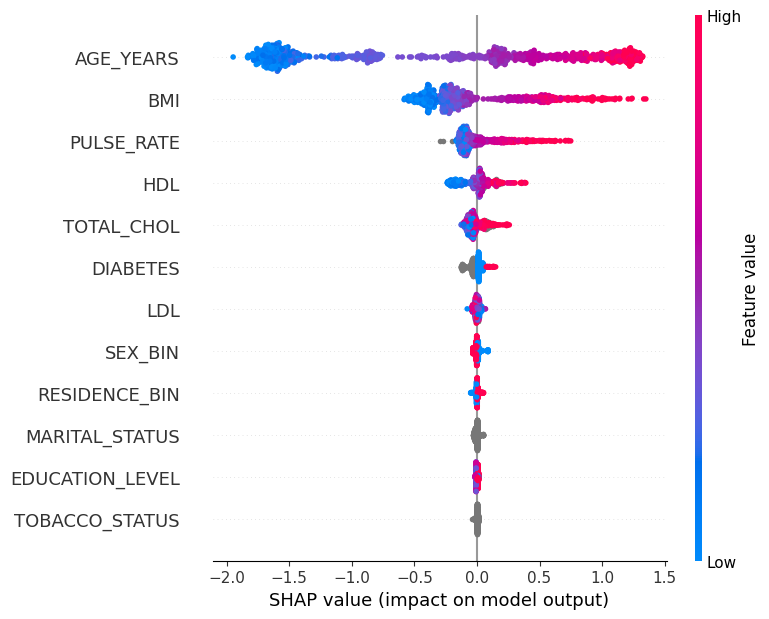

In [537]:
# shap summary plot

shap.summary_plot(
    shap_values,
    X_test_enriched,
    show=False
)
plt.tight_layout()
plt.show()

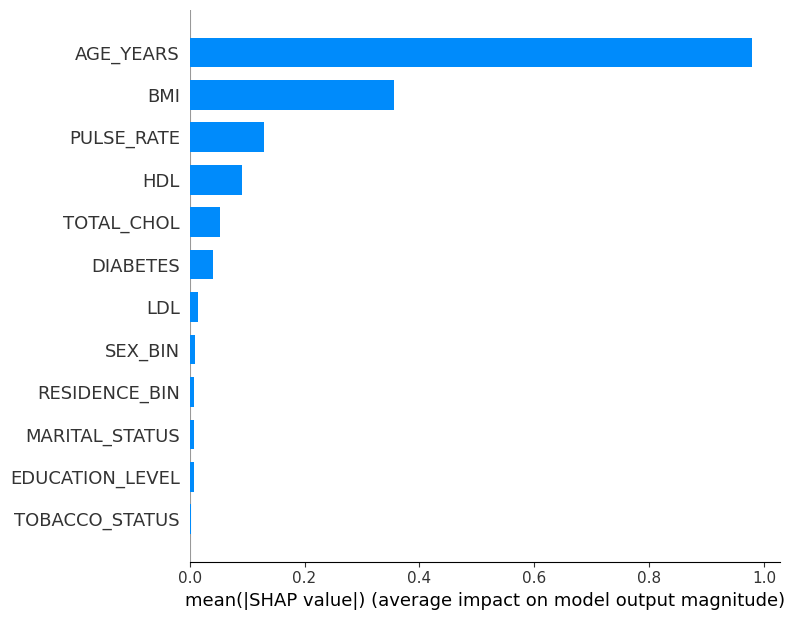

In [538]:
# same plot but in bars 

shap.summary_plot(
    shap_values,
    X_test_enriched,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()

#### 16. Export Results for Reproducibility

Save the final model configurations, thresholds, performance results, and SHAP importance for reproducibility.

In [539]:
# Create Stage 3 output directory

output_dir = Path("../outputs/clinical_enrichment")
output_dir.mkdir(parents=True, exist_ok=True)

In [540]:
# Final performance comparison

comparison.to_csv(
    output_dir / "stage3_performance_comparison.csv",
    index=False
)

# Thresholds
threshold_summary.to_csv(
    output_dir / "stage3_thresholds.csv",
    index=False
)

# SHAP importance
shap_importance.to_csv(
    output_dir / "stage3_shap_importance.csv",
    index=False
)

In [541]:
# Consolidated performance comparison across HyperSense development stages(1-3)

# ------------------------------------------------------------------
# 1. Ghana v1.1 reported performance
# ------------------------------------------------------------------

ghana_v11 = {
    "ROC-AUC": 0.792,
    "Sensitivity": 0.779,
    "Specificity": 0.616,
    "PPV": 0.209,
    "NPV": 0.955,
    "Calibration intercept": np.nan,
    "Calibration slope": np.nan,
    "Brier score": 0.235
}


# ------------------------------------------------------------------
# 2. Stage 1 REMAH transportability evaluation
# ------------------------------------------------------------------

remah_stage1 = {
    "ROC-AUC": 0.747,
    "Sensitivity": 0.906,
    "Specificity": 0.448,
    "PPV": 0.392,
    "NPV": 0.924,
    "Calibration intercept": -1.798,
    "Calibration slope": 1.276,
    "Brier score": 0.276
}


# ------------------------------------------------------------------
# 3. Stage 2 pooled baseline performance
# ------------------------------------------------------------------

stage2_baseline = {
    "ROC-AUC": 0.772,
    "Sensitivity": 0.260,
    "Specificity": 0.946,
    "PPV": 0.502,
    "NPV": 0.860,
    "Calibration intercept": -0.423,
    "Calibration slope": 0.623,
    "Brier score": 0.126
}


# ------------------------------------------------------------------
# 4. Stage 2 final tuned performance
#    Values taken from the finalized Stage 2 comparison.
# ------------------------------------------------------------------

stage2_tuned_overall = {
    "ROC-AUC": 0.8030,
    "Sensitivity": 0.7591,
    "Specificity": 0.6984,
    "PPV": 0.3436,
    "NPV": 0.9331,
    "Calibration intercept": -0.0076,
    "Calibration slope": 0.9889,
    "Brier score": 0.1160
}

stage2_tuned_ghana = {
    "ROC-AUC": 0.7677,
    "Sensitivity": 0.6077,
    "Specificity": 0.7702,
    "PPV": 0.2564,
    "NPV": 0.9377,
    "Calibration intercept": -0.2131,
    "Calibration slope": 0.9188,
    "Brier score": 0.0920
}

stage2_tuned_nigeria = {
    "ROC-AUC": 0.7843,
    "Sensitivity": 0.8783,
    "Specificity": 0.5289,
    "PPV": 0.4217,
    "NPV": 0.9174,
    "Calibration intercept": 0.0870,
    "Calibration slope": 0.9748,
    "Brier score": 0.1619
}


# ------------------------------------------------------------------
# 5. Stage 3 final test-set performance
# ------------------------------------------------------------------

stage3_parsimonious = {
    "ROC-AUC": test_auc.loc[
        test_auc["Model"] == "Parsimonious", "ROC_AUC"
    ].iloc[0],
    "Sensitivity": threshold_metrics_df.loc[
        "Parsimonious", "Sensitivity"
    ],
    "Specificity": threshold_metrics_df.loc[
        "Parsimonious", "Specificity"
    ],
    "PPV": threshold_metrics_df.loc[
        "Parsimonious", "PPV"
    ],
    "NPV": threshold_metrics_df.loc[
        "Parsimonious", "NPV"
    ],
    "Calibration intercept": calibration_results.loc[
        "Parsimonious", "Calibration intercept"
    ],
    "Calibration slope": calibration_results.loc[
        "Parsimonious", "Calibration slope"
    ],
    "Brier score": brier_results.loc[
        brier_results["Model"] == "Parsimonious", "Brier score"
    ].iloc[0]
}

stage3_enriched = {
    "ROC-AUC": test_auc.loc[
        test_auc["Model"] == "Enriched", "ROC_AUC"
    ].iloc[0],
    "Sensitivity": threshold_metrics_df.loc[
        "Enriched", "Sensitivity"
    ],
    "Specificity": threshold_metrics_df.loc[
        "Enriched", "Specificity"
    ],
    "PPV": threshold_metrics_df.loc[
        "Enriched", "PPV"
    ],
    "NPV": threshold_metrics_df.loc[
        "Enriched", "NPV"
    ],
    "Calibration intercept": calibration_results.loc[
        "Enriched", "Calibration intercept"
    ],
    "Calibration slope": calibration_results.loc[
        "Enriched", "Calibration slope"
    ],
    "Brier score": brier_results.loc[
        brier_results["Model"] == "Enriched", "Brier score"
    ].iloc[0]
}


# ------------------------------------------------------------------
# 6. Construct consolidated comparison table
# ------------------------------------------------------------------

metrics = [
    "ROC-AUC",
    "Sensitivity",
    "Specificity",
    "PPV",
    "NPV",
    "Calibration intercept",
    "Calibration slope",
    "Brier score"
]

comparison_all_stages = pd.DataFrame({
    "Metric": metrics,

    "Ghana v1.1 (reported)": [
        ghana_v11[m] for m in metrics
    ],

    "Stage 1 REMAH (full cohort)": [
        remah_stage1[m] for m in metrics
    ],

    "Stage 2 baseline": [
        stage2_baseline[m] for m in metrics
    ],

    "Stage 2 tuned (overall)": [
        stage2_tuned_overall[m] for m in metrics
    ],

    "Stage 2 tuned (Ghana)": [
        stage2_tuned_ghana[m] for m in metrics
    ],

    "Stage 2 tuned (Nigeria)": [
        stage2_tuned_nigeria[m] for m in metrics
    ],

    "Stage 3 parsimonious": [
        stage3_parsimonious[m] for m in metrics
    ],

    "Stage 3 enriched": [
        stage3_enriched[m] for m in metrics
    ]
})

display(comparison_all_stages.round(4))

,Metric,Ghana v1.1 (reported),Stage 1 REMAH (full cohort),Stage 2 baseline,Stage 2 tuned (overall),Stage 2 tuned (Ghana),Stage 2 tuned (Nigeria),Stage 3 parsimonious,Stage 3 enriched
0,ROC-AUC,0.792,0.747,0.772,0.8030,0.7677,0.7843,0.8120,0.8218
1,Sensitivity,0.779,0.906,0.260,0.7591,0.6077,0.8783,0.6906,0.7774
2,Specificity,0.616,0.448,0.946,0.6984,0.7702,0.5289,0.7554,0.7176
3,PPV,0.209,0.392,0.502,0.3436,0.2564,0.4217,0.5737,0.5675
4,NPV,0.955,0.924,0.860,0.9331,0.9377,0.9174,0.8367,0.8712
5,Calibration intercept,NaN,-1.798,-0.423,-0.0076,-0.2131,0.0870,0.0959,0.1346
6,Calibration slope,NaN,1.276,0.623,0.9889,0.9188,0.9748,1.0630,1.1440
7,Brier score,0.235,0.276,0.126,0.1160,0.0920,0.1619,0.1623,0.1577


In [542]:
# Consolidated historical comparison

comparison_all_stages.to_csv(
    output_dir / "stage3_all_stages_comparison.csv",
    index=False
)

In [543]:
# Save model configurations

model_configuration = {
    "random_state": RANDOM_STATE,
    "train_n": len(train),
    "test_n": len(test),
    "analytical_cohort_n": len(analysis_cohort),
    "parsimonious_features": parsimonious_features,
    "enriched_features": enriched_features,
    "parsimonious_best_params": parsimonious_best_params,
    "enriched_best_params": enriched_best_params,
    "parsimonious_threshold": float(parsimonious_threshold),
    "enriched_threshold": float(enriched_threshold),
}

with open(
    output_dir / "stage3_model_configuration.json",
    "w"
) as f:
    json.dump(model_configuration, f, indent=2)

In [546]:
# Save final fitted models
parsimonious_search.best_estimator_.save_model(
    output_dir / "stage3_parsimonious_xgb.json"
)

enriched_search.best_estimator_.save_model(
    output_dir / "stage3_enriched_xgb.json"
)

# And for the sake of deployment/continuity
import joblib

joblib.dump(
    parsimonious_search.best_estimator_,
    output_dir / "stage3_parsimonious_xgb.joblib"
)

joblib.dump(
    enriched_search.best_estimator_,
    output_dir / "stage3_enriched_xgb.joblib"
)

['..\\outputs\\clinical_enrichment\\stage3_enriched_xgb.joblib']

In [547]:
print("Stage 3 outputs saved to:", output_dir)
print([p.name for p in output_dir.iterdir()])

Stage 3 outputs saved to: ..\outputs\clinical_enrichment
['stage3_all_stages_comparison.csv', 'stage3_enriched_xgb.joblib', 'stage3_enriched_xgb.json', 'stage3_model_configuration.json', 'stage3_parsimonious_xgb.joblib', 'stage3_parsimonious_xgb.json', 'stage3_performance_comparison.csv', 'stage3_shap_importance.csv', 'stage3_thresholds.csv']


### 17. Stage 3 Conclusion

Stage 3 evaluated whether clinically enriching the established six-predictor HyperSense model with additional Nigerian REMAH variables improved hypertension risk prediction beyond the parsimonious model.

The analysis used 4,187 REMAH participants, with one clearly out-of-range age observation excluded, leaving 4,182 eligible participants. The hypertension outcome followed the published REMAH definition: hypertension was classified by a five-reading mean systolic BP ≥140 mmHg and/or diastolic BP ≥90 mmHg and/or current antihypertensive drug therapy (`HTN_DR = 1`). The final analytical cohort comprised 4,105 participants after requiring complete data on the six parsimonious predictors. Both models used the same stratified 80/20 train/test split, with 3,284 participants for training and 821 for final evaluation.

The parsimonious model retained the established six predictors: age, sex, educational level, residence, tobacco use, and BMI. The clinically enriched model replaced the redundant binary tobacco-use variable with the three-category tobacco-status representation and additionally incorporated pulse rate, marital status, diagnosed diabetes, HDL cholesterol, total cholesterol, and LDL cholesterol, for 12 distinct predictors. Hypertension-management variables and diabetes-treatment variables were excluded to prevent leakage. Missing values in enriched predictors were retained and handled through XGBoost's native missing-value mechanism.

Both models were developed using XGBoost with training-only 10-fold stratified cross-validation and randomized hyperparameter search. The same optimal configuration was selected for both models: `n_estimators=100`, `max_depth=3`, `learning_rate=0.03`, `subsample=0.7`, `min_child_weight=1`, and `gamma=0.3`. Cross-validated ROC-AUC was 0.8090 for the parsimonious model and 0.8182 for the enriched model.

Youden's index was used on out-of-fold training predictions to select model-specific thresholds before evaluation on the untouched test set. The selected thresholds were 0.3778 for the parsimonious model and 0.3347 for the enriched model.

On the held-out test set, clinical enrichment improved discrimination: ROC-AUC increased from 0.8120 to 0.8218, while PR-AUC increased from 0.6382 to 0.6751. At the selected thresholds, sensitivity increased from 69.1% to 77.7%, while specificity decreased from 75.5% to 71.8%. PPV was similar (57.4% vs. 56.7%), while NPV increased from 83.7% to 87.1%. Accuracy was also similar (73.5% vs. 73.7%). The enriched model achieved a lower Brier score (0.1577 vs. 0.1623), indicating slightly better overall probabilistic accuracy.

Calibration, however, favoured the parsimonious model. Its calibration intercept (0.0959) and slope (1.0630) were closer to the ideal values of 0 and 1 than those of the enriched model (0.1346 and 1.1440). Thus, the enriched model improved discrimination and several classification/probabilistic performance measures, but at the cost of a modest reduction in calibration performance and specificity.

SHAP analysis of the final enriched model showed that age was by far the dominant contributor to model predictions, followed by BMI and pulse rate. HDL, total cholesterol, diabetes, and LDL contributed smaller amounts, while sex, residence, marital status, educational level, and tobacco status made relatively small contributions to the fitted model.

Overall, the findings indicate that clinically enriching HyperSense with additional REMAH-derived variables provides a measurable improvement in discrimination and detection of hypertensive participants beyond the established parsimonious model, while the simpler model retains slightly better calibration. The results support clinical enrichment as a useful direction for further development of HyperSense in the Nigerian setting, while indicating that calibration and generalizability should remain important considerations in subsequent validation.